# Data Profiling & Schema Intelligence

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from itertools import combinations
pd.options.future.infer_string = False

### Data

In [2]:
train = pd.read_pickle("../data/interim/train_merged.pkl")
test = pd.read_pickle("../data/interim/test_merged.pkl")

TARGET = "isFraud"
ID_COLS = ["TransactionID"]
TIME_COL = "TransactionDT"

### Numeric/Categorical/Datetime Separation

In [3]:
exclude_cols = [TARGET] + ID_COLS + [TIME_COL]

numeric_cols = train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = train.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()

numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
categorical_cols = [col for col in categorical_cols if col not in exclude_cols]
datetime_cols = [TIME_COL]

### NaN Ratio Analysis

In [4]:
train_aligned_test = test.reindex(columns=train.columns)

nan_summary = pd.DataFrame({
    "column_name": train.columns,
    "data_type": train.dtypes.astype(str).values,
    "train_nan_count": train.isna().sum().values,
    "train_nan_ratio": (train.isna().mean() * 100).values,
    "test_nan_count": train_aligned_test.isna().sum().values,
    "test_nan_ratio": (train_aligned_test.isna().mean() * 100).values,
    "unique_count": train.nunique(dropna=False).values})

nan_summary = (nan_summary.sort_values("train_nan_ratio", ascending=False).reset_index(drop=True))

nan_summary["nan_severity"] = pd.cut(
    nan_summary["train_nan_ratio"],
    bins=[-0.01, 0, 20, 50, 80, 100],
    labels=["No missing", "Low", "Moderate", "High", "Critical"])

nan_review = (nan_summary.groupby("nan_severity", observed=False).size().reset_index(name="count"))


display(nan_review)

,nan_severity,count
0,No missing,20
1,Low,162
2,Moderate,38
3,High,140
4,Critical,74


### Outlier Analysis

In [5]:
X_outlier = train[numeric_cols].replace([np.inf, -np.inf], np.nan)

missing_ratio = X_outlier.isna().mean()
valid_cols = missing_ratio[missing_ratio <= 0.50].index.tolist()
X_outlier = X_outlier[valid_cols]
X_outlier = X_outlier.dropna(axis=1, how="all")
X_outlier = X_outlier.loc[:, X_outlier.nunique(dropna=True) > 1]

outlier_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("isolation_forest", IsolationForest(
        n_estimators=100,
        contamination=0.03,
        max_samples=10000,
        random_state=42,
        n_jobs=-1))])

outlier_labels = outlier_pipeline.fit_predict(X_outlier)
train["outlier_flag"] = (outlier_labels == -1).astype(int)

outlier_summary = pd.DataFrame({
    "metric": [
        "Numeric features available",
        "Numeric features used",
        "Outlier count",
        "Outlier ratio (%)"],
    "value": [
        len(numeric_cols),
        X_outlier.shape[1],
        train["outlier_flag"].sum(),
        round(train["outlier_flag"].mean() * 100, 2),],})

display(outlier_summary)

,metric,value
0,Numeric features available,400.0
1,Numeric features used,208.0
2,Outlier count,17717.0
3,Outlier ratio (%),3.0


### Target Distribution Analysis

In [6]:
target_distribution = (
    train[TARGET]
    .value_counts(dropna=False)
    .rename_axis(TARGET)
    .reset_index(name="count"))

target_distribution["ratio_percent"] = (target_distribution["count"] / len(train) * 100).round(2)

target_distribution["class_label"] = target_distribution[TARGET].map({
    0: "Non-Fraud",
    1: "Fraud",
}).fillna("Missing")

fraud_rate = target_distribution.loc[
    target_distribution[TARGET] == 1,
    "ratio_percent"].iloc[0]

display(target_distribution)

,isFraud,count,ratio_percent,class_label
0,0,569877,96.5,Non-Fraud
1,1,20663,3.5,Fraud


In [7]:
# Numeric Columns Distribution Summary

numeric_distribution_summary = train[numeric_cols].describe().T

numeric_distribution_summary["skewness"] = train[numeric_cols].skew()
numeric_distribution_summary["kurtosis"] = train[numeric_cols].kurtosis()

numeric_distribution_summary = (
    numeric_distribution_summary
    .reset_index()
    .rename(columns={"index": "column_name"})
    .sort_values("skewness", ascending=False))

display(numeric_distribution_summary.head(30))

,column_name,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
342,V305,590528.0,1.000007,0.002603,1.0,1.0,1.0,1.0,2.0,384.226170,147628.249982
348,V311,590528.0,4.202175,102.374938,0.0,0.0,0.0,0.0,55125.0,323.831374,156542.416947
166,V129,590226.0,8.768944,113.832828,0.0,0.0,0.0,0.0,55125.0,240.274253,102763.136782
346,V309,590528.0,10.995986,116.254277,0.0,0.0,0.0,0.0,55125.0,224.875268,94325.712591
243,V206,139631.0,6.189360,191.474014,0.0,0.0,0.0,0.0,55125.0,207.881617,54107.101724
356,V319,590528.0,18.372476,332.304848,0.0,0.0,0.0,0.0,104060.0,181.833654,47649.899851
306,V269,130430.0,5.997508,207.317539,0.0,0.0,0.0,0.0,55125.0,177.838951,42255.378048
303,V266,130430.0,9.167839,208.038863,0.0,0.0,0.0,0.0,55125.0,175.958772,41661.637649
371,V334,82351.0,9.807015,243.861391,0.0,0.0,0.0,0.0,55125.0,168.472807,34776.335020
172,V135,590226.0,17.250132,293.847563,0.0,0.0,0.0,0.0,90750.0,144.883182,31814.572343


### Rare Categorical Combination Analysis

,column_pair,combination,record_count,fraud_count,fraud_rate_percent,fraud_lift_vs_baseline
91,id_23 + id_34,id_23=IP_PROXY:ANONYMOUS | id_34=match_status:1,41,26,63.41,18.12
86,id_15 + id_23,id_15=Unknown | id_23=IP_PROXY:ANONYMOUS,66,24,36.36,10.39
88,id_16 + id_23,id_16=Missing | id_23=IP_PROXY:ANONYMOUS,66,24,36.36,10.39
10,card4 + M4,card4=discover | M4=M2,37,9,24.32,6.95
7,ProductCD + id_35,ProductCD=S | id_35=F,29,7,24.14,6.90
82,M4 + id_36,M4=M1 | id_36=T,28,5,17.86,5.10
3,ProductCD + id_15,ProductCD=S | id_15=Unknown,24,4,16.67,4.76
25,card4 + id_35,card4=discover | id_35=F,46,7,15.22,4.35
96,id_28 + DeviceType,id_28=Found | DeviceType=Missing,47,7,14.89,4.26
97,id_29 + DeviceType,id_29=Found | DeviceType=Missing,47,7,14.89,4.26


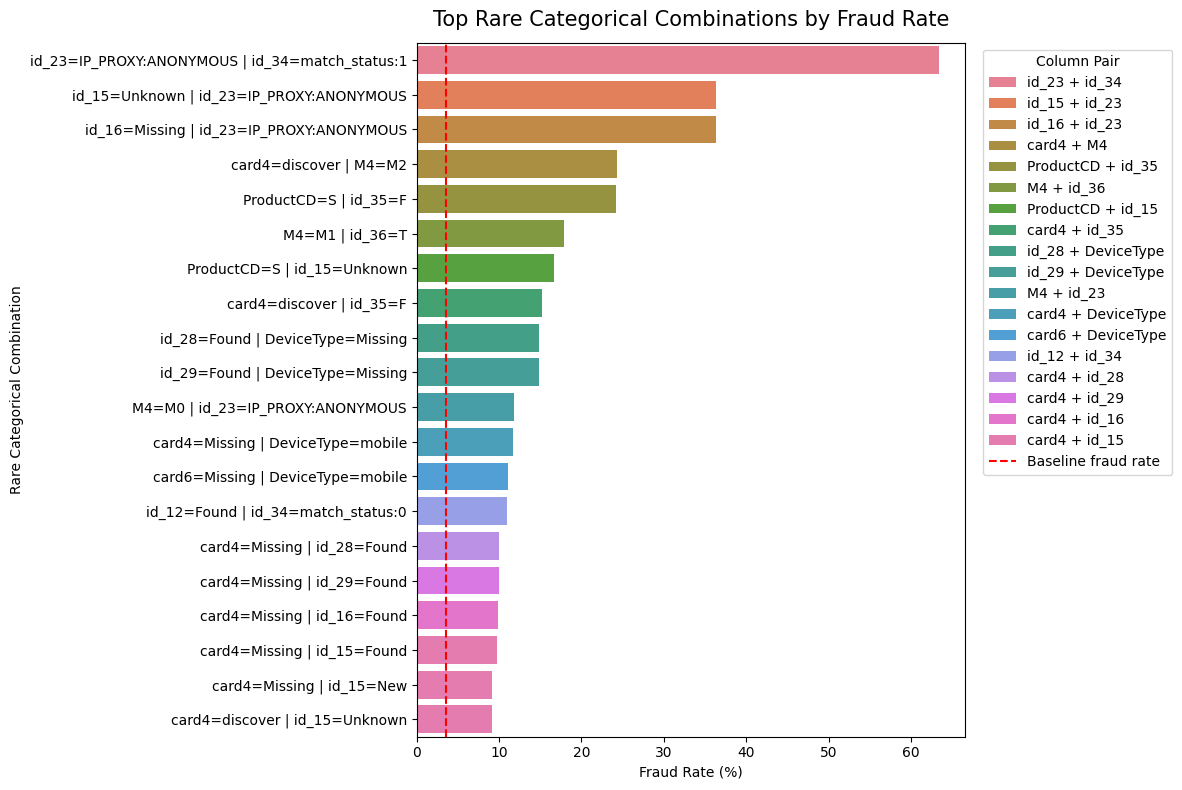

In [8]:
max_unique_values = 50
min_group_count = 20
rare_group_count = 100
top_n = 20

candidate_categorical_cols = [
    col for col in categorical_cols
    if train[col].nunique(dropna=False) <= max_unique_values]

baseline_fraud_rate = train[TARGET].mean()
rare_combination_frames = []

for col_a, col_b in combinations(candidate_categorical_cols, 2):
    grouped = (
        train[[col_a, col_b, TARGET]]
        .fillna("Missing")
        .groupby([col_a, col_b], dropna=False)
        .agg(
            record_count=(TARGET, "count"),
            fraud_count=(TARGET, "sum"),
            fraud_rate=(TARGET, "mean"))
        .reset_index())

    grouped = grouped[
        (grouped["record_count"] >= min_group_count)
        & (grouped["record_count"] <= rare_group_count)
    ].copy()

    if grouped.empty:
        continue

    grouped["column_pair"] = f"{col_a} + {col_b}"
    grouped["combination"] = (
        col_a + "=" + grouped[col_a].astype(str)
        + " | "
        + col_b + "=" + grouped[col_b].astype(str)
    )
    grouped["fraud_rate_percent"] = (grouped["fraud_rate"] * 100).round(2)
    grouped["fraud_lift_vs_baseline"] = (grouped["fraud_rate"] / baseline_fraud_rate).round(2)

    rare_combination_frames.append(grouped[[
        "column_pair",
        "combination",
        "record_count",
        "fraud_count",
        "fraud_rate_percent",
        "fraud_lift_vs_baseline",]])

if rare_combination_frames:
    rare_categorical_combinations = (
        pd.concat(rare_combination_frames, ignore_index=True)
        .sort_values(["fraud_rate_percent", "record_count"], ascending=[False, False])
        .head(top_n))

    display(rare_categorical_combinations)

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=rare_categorical_combinations,
        x="fraud_rate_percent",
        y="combination",
        hue="column_pair",
        dodge=False)

    plt.axvline(baseline_fraud_rate * 100, color="red", linestyle="--", label="Baseline fraud rate")
    plt.title("Top Rare Categorical Combinations by Fraud Rate", fontsize=15, pad=12)
    plt.xlabel("Fraud Rate (%)")
    plt.ylabel("Rare Categorical Combination")
    plt.legend(title="Column Pair", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No rare categorical combinations found with the current thresholds.")

### Column Relationship Analysis

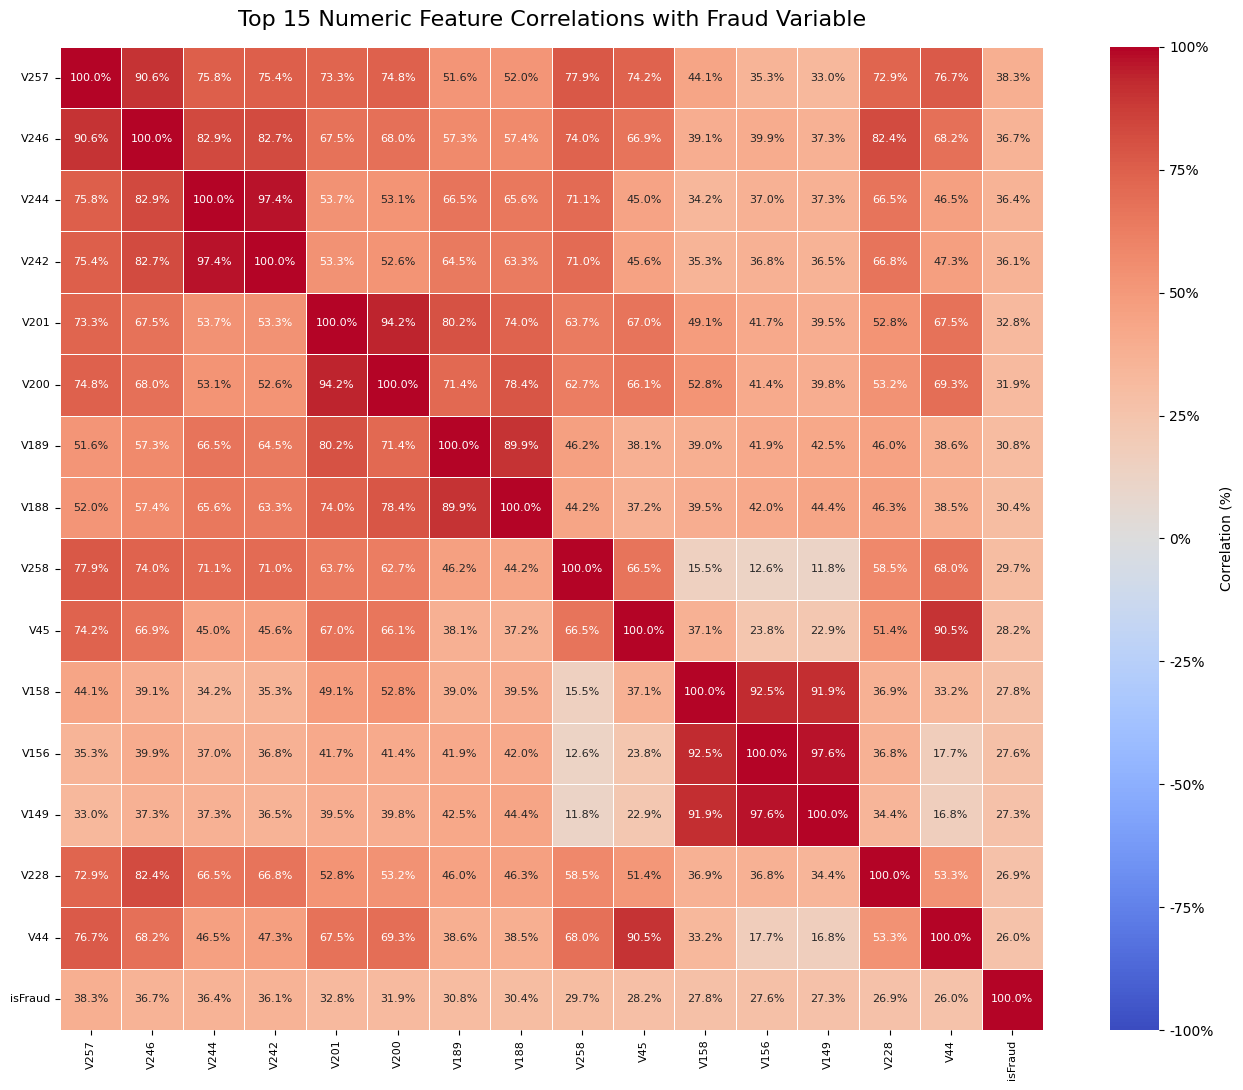

In [9]:
numeric_feature_cols = train.select_dtypes(include=["number"]).columns.drop(
    ["isFraud", "TransactionID", "TransactionDT"],
    errors="ignore")

numeric_target_corr = train[numeric_feature_cols].corrwith(train["isFraud"]).abs().sort_values(ascending=False)

top_n = 15
selected_numeric_cols = numeric_target_corr.head(top_n).index.tolist()

numeric_corr_matrix = train[selected_numeric_cols + ["isFraud"]].corr() * 100
annot_labels = numeric_corr_matrix.round(1).astype(str) + "%"

plt.figure(figsize=(14, 11))

ax = sns.heatmap(
    numeric_corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-100,
    vmax=100,
    linewidths=0.5,
    linecolor="white",
    square=True,
    annot=annot_labels,
    fmt="",
    annot_kws={"size": 8},
    cbar_kws={"label": "Correlation (%)"})

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.0f}%"))

ax.set_title(
    f"Top {top_n} Numeric Feature Correlations with Fraud Variable",
    fontsize=16,
    pad=15)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

### Entity Based Behavioral Pattern Analysis

In [10]:
entity_candidate_cols = [
    col for col in train.columns
    if (
        col.startswith("card")
        or col.startswith("addr")
        or col.startswith("Device")
        or col.startswith("id_")
        or col.startswith("M")
        or col in ["ProductCD", "P_emaildomain", "R_emaildomain"]
    )
]

min_entity_transactions = 10
top_n = 20
entity_behavior_frames = []

for entity_col in entity_candidate_cols:
    entity_behavior = (
        train
        .groupby(entity_col, dropna=False)
        .agg(
            transaction_count=(TARGET, "count"),
            fraud_count=(TARGET, "sum"),
            fraud_rate=(TARGET, "mean"),
            avg_transaction_amount=("TransactionAmt", "mean"),
            median_transaction_amount=("TransactionAmt", "median"),
            first_transaction_time=(TIME_COL, "min"),
            last_transaction_time=(TIME_COL, "max"))
        .reset_index())

    entity_behavior = entity_behavior[
        entity_behavior["transaction_count"] >= min_entity_transactions
    ].copy()

    if entity_behavior.empty:
        continue

    entity_behavior["entity_column"] = entity_col
    entity_behavior["entity_value"] = entity_behavior[entity_col].astype(str)
    entity_behavior["fraud_rate_percent"] = (entity_behavior["fraud_rate"] * 100).round(2)
    entity_behavior["avg_transaction_amount"] = entity_behavior["avg_transaction_amount"].round(2)
    entity_behavior["median_transaction_amount"] = entity_behavior["median_transaction_amount"].round(2)
    entity_behavior["active_time_span"] = (
        entity_behavior["last_transaction_time"] - entity_behavior["first_transaction_time"]
    )

    entity_behavior_frames.append(entity_behavior[[
        "entity_column",
        "entity_value",
        "transaction_count",
        "fraud_count",
        "fraud_rate_percent",
        "avg_transaction_amount",
        "median_transaction_amount",
        "active_time_span",
    ]])

all_entity_behavior = pd.concat(entity_behavior_frames, ignore_index=True)

top_risky_entities = all_entity_behavior.sort_values(
    ["fraud_rate_percent", "transaction_count"],
    ascending=[False, False]
).head(top_n)

display(top_risky_entities)

,entity_column,entity_value,transaction_count,fraud_count,fraud_rate_percent,avg_transaction_amount,median_transaction_amount,active_time_span
7229,DeviceInfo,VS5012 Build/NRD90M,34,34,100.00,21.87,20.84,2503595
7257,DeviceInfo,Z835 Build/NMF26V,25,25,100.00,209.00,250.00,14632224
7189,DeviceInfo,SM-N920A Build/MMB29K,21,21,100.00,40.09,22.39,5344406
5780,id_17,110.0,18,18,100.00,87.50,30.00,7597324
6201,id_20,236.0,18,18,100.00,87.50,30.00,7597324
6359,id_21,657.0,14,14,100.00,79.62,81.97,5088817
6400,id_25,161.0,14,14,100.00,79.62,81.97,5088817
6805,DeviceInfo,Blade L3 Build/KOT49H,12,12,100.00,66.70,66.70,154644
6839,DeviceInfo,G3123 Build/40.0.A.6.175,12,12,100.00,32.97,35.04,2337429
6372,id_21,839.0,11,11,100.00,33.44,31.72,6959403


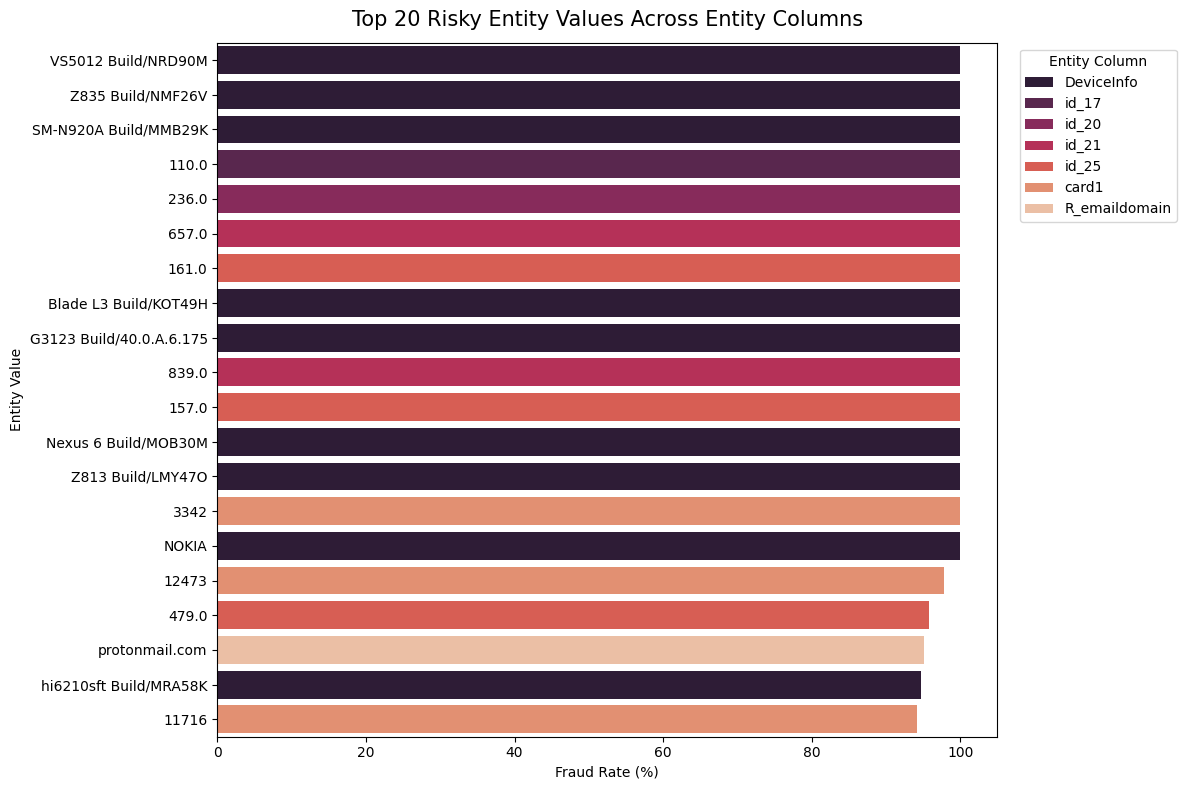

In [11]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_risky_entities,
    x="fraud_rate_percent",
    y="entity_value",
    hue="entity_column",
    dodge=False,
    palette="rocket")

plt.title(f"Top {top_n} Risky Entity Values Across Entity Columns", fontsize=15, pad=12)
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Entity Value")
plt.legend(title="Entity Column", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [12]:
entity_column_review = (
    all_entity_behavior
    .groupby("entity_column")
    .agg(
        retained_entity_values=("entity_value", "count"),
        avg_transaction_count=("transaction_count", "mean"),
        max_transaction_count=("transaction_count", "max"),
        avg_fraud_rate_percent=("fraud_rate_percent", "mean"),
        max_fraud_rate_percent=("fraud_rate_percent", "max"))
    .round(2)
    .reset_index()
    .sort_values("max_fraud_rate_percent", ascending=False))

entity_column_review.head(10)

,entity_column,retained_entity_values,avg_transaction_count,max_transaction_count,avg_fraud_rate_percent,max_fraud_rate_percent
0,DeviceInfo,514,1140.77,471874,14.42,100.00
46,id_25,56,10530.71,585408,15.74,100.00
16,card1,4298,130.87,14932,2.75,100.00
41,id_20,154,3829.70,451279,6.64,100.00
42,id_21,56,10529.43,585381,16.39,100.00
38,id_17,52,11352.40,451171,9.14,100.00
13,R_emaildomain,59,10008.86,453249,4.57,95.12
24,id_03,16,36906.56,524216,35.17,94.12
47,id_26,40,14759.40,585377,11.31,91.67
34,id_13,34,17367.18,463220,16.65,84.62


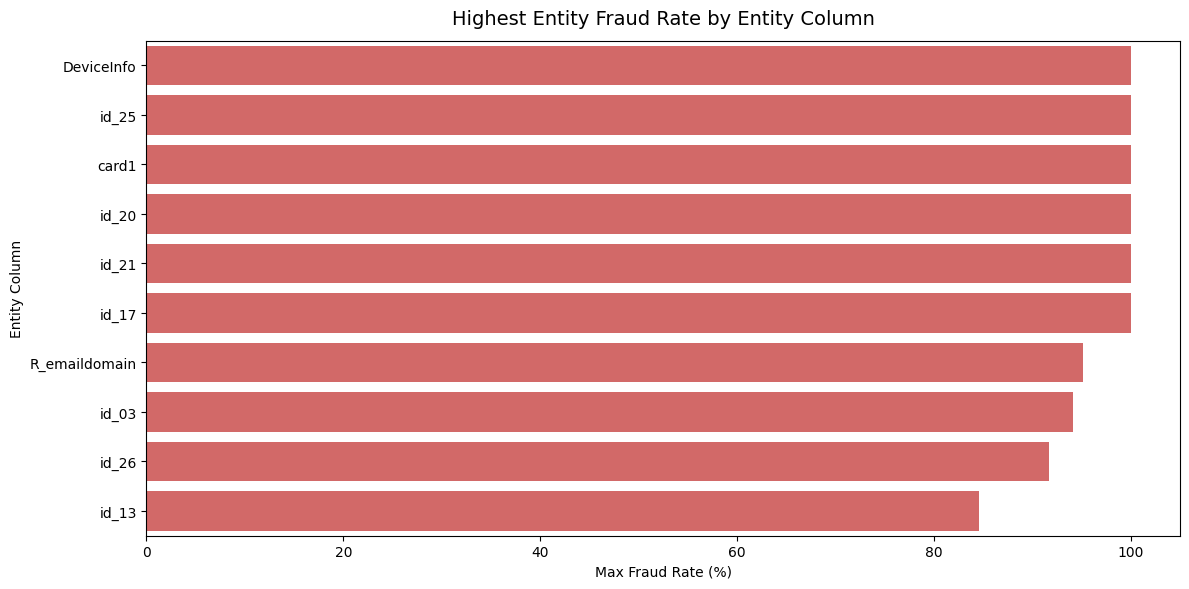

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=entity_column_review.head(10),
    x="max_fraud_rate_percent",
    y="entity_column",
    color="#E45756")

plt.title("Highest Entity Fraud Rate by Entity Column", fontsize=14, pad=12)
plt.xlabel("Max Fraud Rate (%)")
plt.ylabel("Entity Column")
plt.tight_layout()
plt.show()

## Summary of Findings

The dataset is highly imbalanced, with fraud cases representing only a small portion of transactions. High missingness ratios, rare categorical patterns, entity-based behaviors, and numeric anomalies indicate that both data quality and behavioral structures play an important role in fraud detection and feature engineering.